In [2]:
from metloom.pointdata import SnotelPointData
from datetime import datetime
import os
import glob
import pandas as pd
import xarray as xr
import rioxarray as rxr
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

from scores.continuous import multiplicative_bias
from scores.continuous.correlation import pearsonr
from scores.continuous import kge

import matplotlib.pyplot as plt

os.environ['PROJ_DATA'] = "C:/Users/RDCRLSMC/AppData/Local/miniconda3/envs/SIRO/Library/share/proj"
from model_comparison_functions import x_y_snotel

In [3]:
base_dir = "C:/Users/RDCRLSMC/Desktop/SIRO/time_series/"

##All HMS uploads are Task 1
HMS = os.path.join(base_dir, "HMS_snow_grids/")
HMS_EB = glob.glob(os.path.join(HMS, "EB/snow_depth_tif/", "*.tiff"))
HMS_TI = glob.glob(os.path.join(HMS, "TI/snow_depth_tif/", "*.tif"))

SM = os.path.join(base_dir, "SM/")
SM_t1 = glob.glob(os.path.join(SM, "Task1/", "*.nc"))
SM_t2 = glob.glob(os.path.join(SM, "Task2/", "*.nc"))


In [4]:
snotel_point_MCS = SnotelPointData("637:ID:SNTL", "MCS") # define the snotel ID
snotel_point_BB = SnotelPointData("978:ID:SNTL", "Bogus Basin") # define the snotel ID

MCS_SNOTEL = snotel_point_MCS.get_daily_data(
    datetime(2022, 10, 1), datetime(2025, 10, 1),
    [snotel_point_MCS.ALLOWED_VARIABLES.SNOWDEPTH])
    
BB_SNOTEL = snotel_point_BB.get_daily_data(
    datetime(2022, 10, 1), datetime(2025, 10, 1),
    [snotel_point_BB.ALLOWED_VARIABLES.SNOWDEPTH])  
MCS_SNOTEL["SNOWDEPTH (m)"] = MCS_SNOTEL["SNOWDEPTH"] * 0.0254 # convert snow depth from inches to meters
BB_SNOTEL["SNOWDEPTH (m)"] = BB_SNOTEL["SNOWDEPTH"] * 0.0254 # convert snow depth from inches to meters
MCS_SNOTEL = MCS_SNOTEL.reset_index()
BB_SNOTEL = BB_SNOTEL.reset_index()


In [5]:
MCS = x_y_snotel(snotel_point_MCS)
BB = x_y_snotel(snotel_point_BB)

In [11]:
def build_timeseries_netcdf(filelist, modelname, point):

    dfs = []

    for file in filelist:
        ds = xr.open_dataset(file, engine = 'netcdf4')

        # select nearest grid point
        ts = ds['SD'].sel(
            x=point[0],
            y=point[1],
            method="nearest"
        )

        # convert to dataframe WITH time preserved
        df = ts.to_dataframe(name=modelname).reset_index()

        # keep only relevant columns
        dfs.append(df[['time', modelname]])

    # combine all files into one time series
    out = pd.concat(dfs, ignore_index=True)

    # optional: sort by time
    out = out.sort_values('time').reset_index(drop=True)

    return out

In [12]:
def build_timeseries_tif(filelist, modelname, point):

    rasters = []

    for file in filelist:

        depth = rxr.open_rasterio(file).squeeze(drop=True)
        name, ext = os.path.splitext(os.path.basename(file))

        if 'TI' in name:
            parts = "-".join(name.split("_")[3:6])

        elif 'eb' in name:
            parts = "-".join(name.split("_")[7:10])

        else:
            continue

        dt = datetime.strptime(parts, "%Y-%m-%dT%H%M")
        depth = depth.expand_dims(datetime=[dt])
        rasters.append(depth)

    depth_ts = xr.concat(rasters, dim="datetime")
    ts = depth_ts.sel(
        x=point[0],
        y=point[1],
        method="nearest"
    )
    ts = ts * 0.0254
    df = ts.to_dataframe(name=modelname).reset_index()
    return df[["datetime", modelname]]

In [13]:
df_eb_MCS = build_timeseries_tif(HMS_EB, "HMS_EB", MCS)
df_ti_MCS = build_timeseries_tif(HMS_TI, "HMS_TI", MCS)
SM_t1_MCS = build_timeseries_netcdf(SM_t1, "SnowModel", MCS)


In [14]:
df = df_eb_MCS.merge(df_ti_MCS, on="datetime", how="outer")
df["datetime"] = pd.to_datetime(df["datetime"])

In [15]:
df["date"] = df["datetime"].dt.date
MCS_SNOTEL["date"] = MCS_SNOTEL["datetime"].dt.date
SM_t1_MCS["date"] = SM_t1_MCS["time"].dt.date


In [16]:
merged_df = pd.merge(
    df[['HMS_EB', 'HMS_TI', 'date']],
    MCS_SNOTEL[['date', 'SNOWDEPTH (m)']],
    on="date",
    how="left"
)

merged_df = pd.merge(
    merged_df,
    SM_t1_MCS[['date', 'SnowModel']],
    on="date",
    how="left"
)

In [17]:
merged_df

,HMS_EB,HMS_TI,date,SNOWDEPTH (m),SnowModel
0,0.000000,0.0,2022-10-02,0.0,0.0
1,0.000000,0.0,2022-10-03,0.0,0.0
2,0.000000,0.0,2022-10-04,0.0,0.0
3,0.000000,0.0,2022-10-05,0.0,0.0
4,0.000000,0.0,2022-10-06,0.0,0.0
...,...,...,...,...,...
967,0.233347,0.0,2025-05-26,0.0,0.0
968,0.178705,0.0,2025-05-27,0.0,0.0
969,0.129929,0.0,2025-05-28,0.0,0.0
970,0.061873,0.0,2025-05-29,0.0,0.0


In [40]:
merged_df = merged_df.set_index('date')
ds = xr.Dataset.from_dataframe(merged_df)

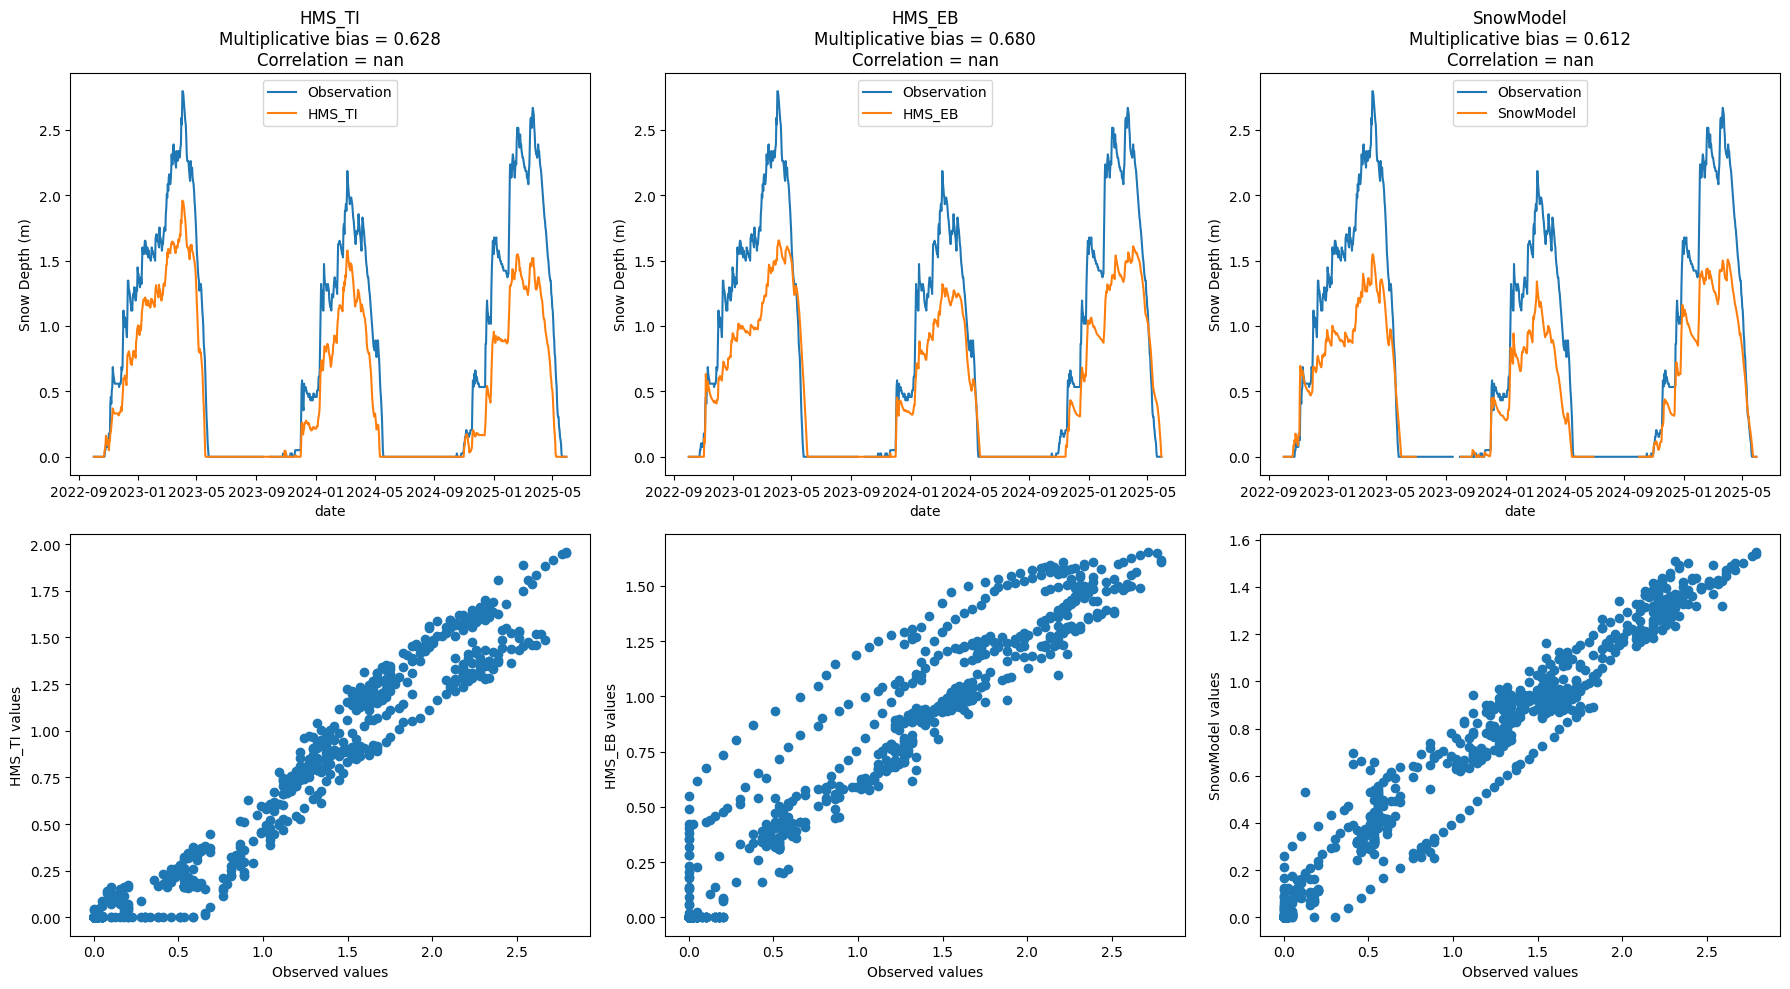

In [41]:

obs = ds['SNOWDEPTH (m)']
fcst1 = ds['HMS_TI']
fcst2 = ds['HMS_EB']
fcst3 = ds['SnowModel']

forecasts = [
    ("HMS_TI", fcst1),
    ("HMS_EB", fcst2),
    ("SnowModel", fcst3)
]


fig, axs = plt.subplots(2, 3, figsize=(18, 10))


for i, (name, fcst) in enumerate(forecasts):

    # -------------------------
    # Time series plot
    # -------------------------
    obs.plot(ax=axs[0, i], label="Observation")
    fcst.plot(ax=axs[0, i], label=name)

    axs[0, i].set_ylabel("Snow Depth (m)")
    axs[0, i].legend()

    # Scatter plot
    axs[1, i].scatter(obs.values, fcst.values)
    axs[1, i].set_xlabel("Observed values")
    axs[1, i].set_ylabel(f"{name} values")


    bias = multiplicative_bias(fcst, obs).item()
    corr, _ = pearsonr(fcst.values, obs.values)

    axs[0, i].set_title(
        f"{name}\n"
        f"Multiplicative bias = {bias:.3f}\n"
        f"Correlation = {corr:.2f}"
    )

plt.tight_layout()
plt.show()